<a href="https://colab.research.google.com/github/ankit-kr6/LEARNING-ML/blob/main/video_38.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer,MissingIndicator
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!kaggle datasets download -d yasserh/titanic-dataset

Dataset URL: https://www.kaggle.com/datasets/yasserh/titanic-dataset
License(s): CC0-1.0
titanic-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
import zipfile
with zipfile.ZipFile('titanic-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

In [ ]:
df=pd.read_csv('Titanic-Dataset.csv',usecols=['Age','Fare','Survived'])

In [ ]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


### RANDOM **IMPUTATION**

APPLING IN Numerical DATA

In [ ]:
df.isnull().mean()*100

,0
Survived,0.00000
Age,19.86532
Fare,0.00000


In [ ]:
x=df.drop(columns=['Survived'])
y=df['Survived']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [ ]:
x_train['Age_imputed']=x_train["Age"]
x_test['Age_imputed']=x_test["Age"]

In [ ]:
# 1. HARD RESET: Create a fresh copy of the original Age column
# This guarantees we wipe out any old mistakes from previous cell runs
x_train['Age_imputed'] = x_train['Age'].copy()
x_test['Age_imputed'] = x_test['Age'].copy()

# 2. Count exactly how many holes exist right this second
train_missing_count = x_train['Age_imputed'].isnull().sum()
test_missing_count = x_test['Age_imputed'].isnull().sum()

# 3. Pull the exact right number of samples and assign them using .loc
x_train.loc[x_train['Age_imputed'].isnull(), 'Age_imputed'] = x_train['Age'].dropna().sample(train_missing_count).values

# Notice we use train_missing_count for the train set, but test_missing_count for the test set
# But we STILL pull the actual random numbers from the X_train pool to prevent Data Leakage!
x_test.loc[x_test['Age_imputed'].isnull(), 'Age_imputed'] = x_train['Age'].dropna().sample(test_missing_count).values

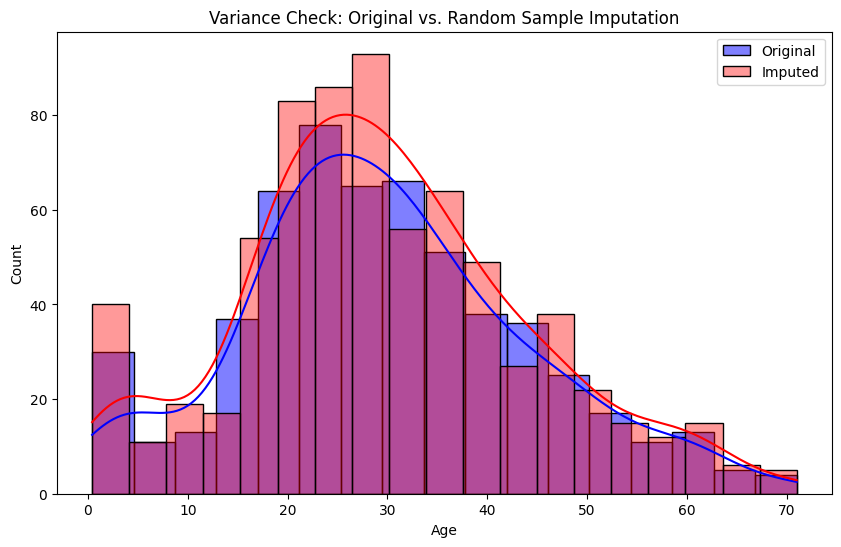

In [ ]:
plt.figure(figsize=(10, 6))

# Using your lowercase x_train
sns.histplot(x_train['Age'], kde=True, label='Original', color='blue', alpha=0.5)
sns.histplot(x_train['Age_imputed'], kde=True, label='Imputed', color='red', alpha=0.4)

plt.legend()
plt.title("Variance Check: Original vs. Random Sample Imputation")
plt.show()

In [ ]:
print('original variable variance:',x_train['Age'].var())
print('imputed variable variance:',x_train['Age_imputed'].var())

original variable variance: 204.3495133904614
imputed variable variance: 208.16805564385484


In [ ]:
x_train[['Fare','Age_imputed','Age']].cov()

,Fare,Age_imputed,Age
Fare,2368.246832,61.380518,71.512440
Age_imputed,61.380518,208.168056,204.349513
Age,71.512440,204.349513,204.349513


<Axes: >

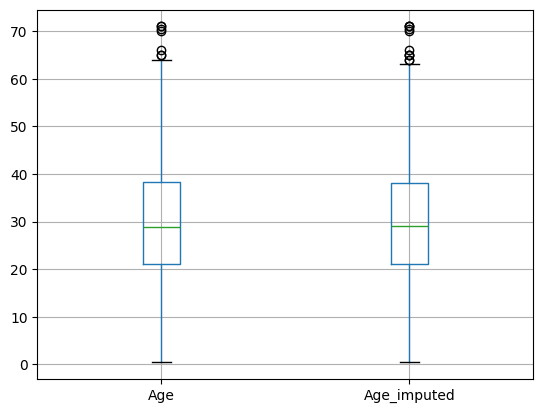

In [ ]:
x_train[['Age','Age_imputed']].boxplot()

In [ ]:
#sample_value=x_train['Age'].dropna().sample(1,random_state=int(observation['Fare']))

Applying in categorical data

In [ ]:
!kaggle datasets download -d rangalamahesh/house-prices-dataset

Dataset URL: https://www.kaggle.com/datasets/rangalamahesh/house-prices-dataset
License(s): apache-2.0
house-prices-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
import zipfile
with zipfile.ZipFile('house-prices-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

In [ ]:
data=pd.read_csv('train.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [ ]:
data.isnull().mean()*100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


In [ ]:
X=data
Y=data['SalePrice']

In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [ ]:
X_train['GarageQual_imputed']=X_train["GarageQual"]
X_test['GarageQual_imputed']=X_test["GarageQual"]

X_train['FireplaceQu_imputed']=X_train["FireplaceQu"]
X_test['FireplaceQu_imputed']=X_test["FireplaceQu"]

In [ ]:
# Random Sample Imputation for Garage Quality
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual_imputed'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual_imputed'].isnull().sum()).values

# Random Sample Imputation for Fireplace Quality
X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu_imputed'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu_imputed'].isnull().sum()).values


/tmp/ipykernel_4152/2736180237.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual_imputed'].isnull().sum()).va

In [ ]:
temp=pd.concat([
    X_train['GarageQual'].value_counts()/len(X_train['GarageQual'].dropna()),
    X_train['GarageQual_imputed'].value_counts()/len(X_train)
],axis=1)
temp.columns=['original','imputed']
temp


,original,imputed
TA,0.951043,0.952911
Fa,0.037171,0.035959
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [ ]:
temp=pd.concat([
    X_train['FireplaceQu'].value_counts()/len(X_train['FireplaceQu'].dropna()),
    X_train['FireplaceQu_imputed'].value_counts()/len(X_train)
],axis=1)
temp.columns=['original','imputed']
temp

,original,imputed
Gd,0.494272,0.494863
TA,0.412439,0.411815
Fa,0.040917,0.042808
Po,0.027823,0.025685
Ex,0.024550,0.024829


# MISSING INDICATOR

In [ ]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
X=df.drop(columns=['Survived'])
Y=df['Survived']

In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [ ]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [ ]:
si=SimpleImputer()
X_train_trf=si.fit_transform(X_train)
X_test_trf=si.transform(X_test)

In [ ]:
# from sklearn.linear_model import LogisticRegression
clf=LogisticRegression()
clf.fit(X_train_trf,Y_train)
y_pred=clf.predict(X_test_trf)
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,y_pred)

0.6145251396648045

In [ ]:
mi=MissingIndicator()
mi.fit(X_train)

MissingIndicator()

In [ ]:
X_train_missing=mi.transform(X_train)
X_test_missing=mi.transform(X_test)

In [ ]:
X_train['Age_NA']=X_train_missing
X_test['Age_NA']=X_test_missing

In [ ]:
si=SimpleImputer()
X_train_trf2=si.fit_transform(X_train)
X_test_trf2=si.transform(X_test)

In [ ]:
clf=LogisticRegression()
clf.fit(X_train_trf2,Y_train)
y_pred=clf.predict(X_test_trf2)
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,y_pred)

0.6312849162011173

without using the MissingIndicator

In [ ]:
si=SimpleImputer(add_indicator=True)
X_train=si.fit_transform(X_train)
X_test=si.transform(X_test)

In [ ]:
clf=LogisticRegression()
clf.fit(X_train_trf2,Y_train)
y_pred=clf.predict(X_test_trf2)
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,y_pred)

0.6312849162011173